# 0. installation

In [1]:
!pip install -q datasets soundfile librosa torchaudio scikit-learn

#1. import

In [5]:
from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from scipy import stats
from numpy.linalg import norm
from collections import defaultdict
from IPython.display import Audio, display


import numpy as np
import librosa
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

random.seed(42)
np.random.seed(42)

#2. load data

In [7]:
# ─────────────────────────────────────────────
# 2. Load Data
# ─────────────────────────────────────────────
print("Loading ESC-50 dataset...")
esc50 = load_dataset("ashraq/esc50")
esc50_train = esc50["train"]
print(f"Dataset size: {len(esc50_train)} samples, {len(set(esc50_train['category']))} classes\n")
sample = esc50_train[0]

Loading ESC-50 dataset...


Repo card metadata block was not found. Setting CardData to empty.


Dataset size: 2000 samples, 50 classes



## 2.1 data info

### 2.1.1. data structure

#### ESC-50 Dataset Structure

| Field        | Type               | Description                                                                                     |
|--------------|--------------------|-------------------------------------------------------------------------------------------------|
| `filename`   | `str`              | Name of the audio file (e.g., `1-100032-A-0.wav`).                                             |
| `fold`       | `int` (1 to 5)     | Cross-validation fold number (4 training folds, 1 testing fold).                                |
| `target`     | `int` (0–49)       | Numeric label corresponding to one of the 50 sound classes.                                    |
| `category`   | `str`              | Text name of the class (e.g., `dog`, `rain`, `siren`).                                          |
| `esc10`      | `bool`             | Boolean: `True` if the clip is part of the ESC-10 subset (10 classes with CC BY license).         |
| `src_file`   | `int`              | Original sound ID from Freesound.org.                                                            |
| `take`       | `str`              | Letter indicating a variant of the source recording (e.g., `A`, `B`).                         |
| `audio`      | `AudioDecoder`     | Hugging Face audio object containing the waveform and sampling rate.                            |

---

### List of 50 Sound Classes (ESC-50)

| ID  | Class                  |
|-----|------------------------|
| 00  | airplane               |
| 01  | breathing               |
| 02  | brushing_teeth          |
| 03  | can_opening             |
| 04  | car_horn                |
| 05  | cat                     |
| 06  | chainsaw                |
| 07  | chirping_birds          |
| 08  | church_bells            |
| 09  | clapping                |
| 10  | clock_alarm             |
| 11  | clock_tick              |
| 12  | coughing                |
| 13  | cow                     |
| 14  | crackling_fire          |
| 15  | crickets                |
| 16  | crow                    |
| 17  | crying_baby             |
| 18  | dog                     |
| 19  | door_wood_creaks        |
| 20  | door_wood_knock         |
| 21  | drinking_sipping        |
| 22  | engine                  |
| 23  | fireworks               |
| 24  | footsteps               |
| 25  | frog                    |
| 26  | glass_breaking          |
| 27  | hand_saw                |
| 28  | helicopter              |
| 29  | hen                     |
| 30  | insects                 |
| 31  | keyboard_typing         |
| 32  | laughing                |
| 33  | mouse_click             |
| 34  | pig                     |
| 35  | pouring_water           |
| 36  | rain                    |
| 37  | rooster                 |
| 38  | sea_waves               |
| 39  | sheep                   |
| 40  | siren                   |
| 41  | sneezing                |
| 42  | snoring                 |
| 43  | thunderstorm            |
| 44  | toilet_flush            |
| 45  | train                   |
| 46  | vacuum_cleaner          |
| 47  | washing_machine         |
| 48  | water_drops             |
| 49  | wind                    |

---
**Total number of classes:** 50
**Number of examples per class:** 40


### 2.1.2. general info

#### 2.1.1.0 obvious info

In [8]:
print(esc50_train)

Dataset({
    features: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'audio'],
    num_rows: 2000
})


In [9]:
esc50_train.info

DatasetInfo(description='', citation='', homepage='', license='', features={'filename': Value('string'), 'fold': Value('int64'), 'target': Value('int64'), 'category': Value('string'), 'esc10': Value('bool'), 'src_file': Value('int64'), 'take': Value('string'), 'audio': Audio(sampling_rate=None, decode=True, stream_index=None)}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='esc50', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=882230336, num_examples=2000, shard_lengths=None, dataset_name='esc50')}, download_checksums={'hf://datasets/ashraq/esc50@e3e2a63ffff66b9a9735524551e3818e96af03ee/data/train-00000-of-00002-2f1ab7b824ec751f.parquet': {'num_bytes': 386533721, 'checksum': None}, 'hf://datasets/ashraq/esc50@e3e2a63ffff66b9a9735524551e3818e96af03ee/data/train-00001-of-00002-27425e5c1846b494.parquet': {'num_bytes': 386787270, 'checksum': None}}, download_size=773320991, post_processing_size=None, dataset_size=

#### 2.1.1.1. categoies

In [10]:
categories = esc50_train.unique("category")

In [11]:
categories_sorted = sorted(categories)

# Affiche
print(f"Nombre de classes: {len(categories_sorted)}")
for idx, cat in enumerate(categories_sorted):
    print(f"{idx:02d}: {cat}")

Nombre de classes: 50
00: airplane
01: breathing
02: brushing_teeth
03: can_opening
04: car_horn
05: cat
06: chainsaw
07: chirping_birds
08: church_bells
09: clapping
10: clock_alarm
11: clock_tick
12: coughing
13: cow
14: crackling_fire
15: crickets
16: crow
17: crying_baby
18: dog
19: door_wood_creaks
20: door_wood_knock
21: drinking_sipping
22: engine
23: fireworks
24: footsteps
25: frog
26: glass_breaking
27: hand_saw
28: helicopter
29: hen
30: insects
31: keyboard_typing
32: laughing
33: mouse_click
34: pig
35: pouring_water
36: rain
37: rooster
38: sea_waves
39: sheep
40: siren
41: sneezing
42: snoring
43: thunderstorm
44: toilet_flush
45: train
46: vacuum_cleaner
47: washing_machine
48: water_drops
49: wind


#### 2.1.1.2. counts per label

In [12]:
from collections import Counter

cat_counts = Counter(esc50_train["category"])

for cat, count in cat_counts.items():
    print(f"{cat}: {count}")

dog: 40
chirping_birds: 40
vacuum_cleaner: 40
thunderstorm: 40
door_wood_knock: 40
can_opening: 40
crow: 40
clapping: 40
fireworks: 40
chainsaw: 40
airplane: 40
mouse_click: 40
pouring_water: 40
train: 40
sheep: 40
water_drops: 40
church_bells: 40
clock_alarm: 40
keyboard_typing: 40
wind: 40
footsteps: 40
frog: 40
cow: 40
brushing_teeth: 40
car_horn: 40
crackling_fire: 40
helicopter: 40
drinking_sipping: 40
rain: 40
insects: 40
laughing: 40
hen: 40
engine: 40
breathing: 40
crying_baby: 40
hand_saw: 40
coughing: 40
glass_breaking: 40
snoring: 40
toilet_flush: 40
pig: 40
washing_machine: 40
clock_tick: 40
sneezing: 40
rooster: 40
sea_waves: 40
siren: 40
cat: 40
door_wood_creaks: 40
crickets: 40


#### 2.1.1.3. data type

In [13]:
print({k: type(esc50_train[0][k]) for k in esc50_train.features.keys()})

{'filename': <class 'str'>, 'fold': <class 'int'>, 'target': <class 'int'>, 'category': <class 'str'>, 'esc10': <class 'bool'>, 'src_file': <class 'int'>, 'take': <class 'str'>, 'audio': <class 'datasets.features._torchcodec.AudioDecoder'>}


### 2.1.3. sample info

#### 2.1.2.1. file info

In [14]:
sample

{'filename': '1-100032-A-0.wav',
 'fold': 1,
 'target': 0,
 'category': 'dog',
 'esc10': True,
 'src_file': 100032,
 'take': 'A',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x79d0da710800>}

#### 2.1.2.2. waveform and sampling frequency

In [15]:
# Retrieve the waveform (audio signal) and sampling frequency
waveform = sample["audio"]["array"]  # Numpy array of the audio signal
sampling_rate = sample["audio"]["sampling_rate"]  # Sampling frequency (e.g., 44,100 Hz)

print(f"Waveform shape: {waveform.shape}")
print(f"Sampling rate: {sampling_rate} Hz")

Waveform shape: (220500,)
Sampling rate: 44100 Hz


#### 2.1.2.3. play audio

In [16]:
display(Audio(waveform, rate=sampling_rate))

#3. Basic Audio Preprocessing

## 3.1. Extract Waveform and Sampling Rate



In [17]:
def extract_waveform(sample):
    """For each audio sample, extract the waveform and sampling rate:"""
    waveform = sample["audio"]["array"]  # Shape: (num_samples,)
    sampling_rate = sample["audio"]["sampling_rate"]
    return waveform, sampling_rate

### 3.1.1. example

In [18]:
# Example usage
waveform, sr = extract_waveform(sample)
print(f"Waveform shape: {waveform.shape}, Sampling rate: {sr} Hz")

Waveform shape: (220500,), Sampling rate: 44100 Hz


## 3.2. resampling 44khz -> 16khz

In [19]:
def resample_audio(waveform, original_sr, target_sr=16000):
    return librosa.resample(waveform, orig_sr=original_sr, target_sr=target_sr)

### 3.2.1. example

In [20]:
resampled_waveform = resample_audio(waveform, sr, target_sr=16000)
print(f"Resampled waveform shape: {resampled_waveform.shape}")

Resampled waveform shape: (80000,)


## 3.3. feature extraction

In [21]:
def waveform_to_logmel(waveform, sr):

    mel_spec = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=128
    )

    logmel = librosa.power_to_db(mel_spec, ref=np.max)

    return logmel

### 3.3.1. example

In [22]:
logmel = waveform_to_logmel(waveform, sr)

print(logmel.shape)

(128, 431)


## 3.4. embeding baseline

In [23]:
def point_embedding(logmel):
    # flatten simple baseline
    return logmel.mean(axis=1)

def cosine_similarity(a, b):
    # baseline similarity
    return np.dot(a, b) / (norm(a) * norm(b))

### 3.4.1. example

In [24]:
emb = point_embedding(logmel)
print(emb.shape)

(128,)


## 3.5. embedding subspace (HyperCLAP)

In [25]:
def subspace_embedding(logmel, k=4):
    pca = PCA(n_components=k)
    pca.fit(logmel.T)
    Z = pca.components_.T   # base orthonormale
    return Z

def subspace_similarity(Z1, Z2):
    M = Z1.T @ Z2
    return np.linalg.norm(M, "fro")**2 / Z1.shape[1]


In [26]:
def normalize_waveform(w):
    """Unit-norm normalisation to remove loudness confound"""
    n = norm(w)
    return w / n if n > 1e-8 else w

# 4. testing intution (insight)

In [27]:
sample1 = esc50_train[0]
sample2 = esc50_train[1]

w1, sr1 = extract_waveform(sample1)
w2, sr2 = extract_waveform(sample2)

logmel1 = waveform_to_logmel(w1, sr1)
logmel2 = waveform_to_logmel(w2, sr2)

p1 = point_embedding(logmel1)
p2 = point_embedding(logmel2)

Z1 = subspace_embedding(logmel1)
Z2 = subspace_embedding(logmel2)

print("cosine:", cosine_similarity(p1,p2))
print("subspace:", subspace_similarity(Z1,Z2))

cosine: 0.96286666
subspace: 0.4367617


In [28]:
mix = w1 + w2

logmel_mix = waveform_to_logmel(mix, sr1)

p_mix = point_embedding(logmel_mix)
Z_mix = subspace_embedding(logmel_mix)

print("cosine mix-bird:", cosine_similarity(p_mix,p1))
print("subspace mix-bird:", subspace_similarity(Z_mix,Z1))

cosine mix-bird: 0.96731544
subspace mix-bird: 0.46020922


In [29]:
N = 2000

results = []

for i in range(N):

    # pick two random samples
    idx1 = random.randint(0, len(esc50_train)-1)
    idx2 = random.randint(0, len(esc50_train)-1)

    sample1 = esc50_train[idx1]
    sample2 = esc50_train[idx2]

    w1, sr1 = extract_waveform(sample1)
    w2, sr2 = extract_waveform(sample2)

    logmel1 = waveform_to_logmel(w1, sr1)
    logmel2 = waveform_to_logmel(w2, sr2)

    # embeddings
    p1 = point_embedding(logmel1)
    p2 = point_embedding(logmel2)

    Z1 = subspace_embedding(logmel1)
    Z2 = subspace_embedding(logmel2)

    # similarity
    cos = cosine_similarity(p1, p2)
    sub = subspace_similarity(Z1, Z2)

    # mixture
    mix = w1 + w2
    logmel_mix = waveform_to_logmel(mix, sr1)

    p_mix = point_embedding(logmel_mix)
    Z_mix = subspace_embedding(logmel_mix)

    cos_mix = cosine_similarity(p_mix, p1)
    sub_mix = subspace_similarity(Z_mix, Z1)

    results.append({
        "pair": i,
        "class1": sample1["category"],
        "class2": sample2["category"],
        "cosine": cos,
        "subspace": sub,
        "cos_mix": cos_mix,
        "sub_mix": sub_mix
    })

# -----------------------------
# Create DataFrame
# -----------------------------

df = pd.DataFrame(results)

# optional: nicer column names
df = df.rename(columns={
    "class1": "Class1",
    "class2": "Class2",
    "cosine": "Cosine",
    "subspace": "Subspace",
    "cos_mix": "Cosine_mix",
    "sub_mix": "Subspace_mix"
})

df['subspace_gain']=df['Subspace_mix']-df['Subspace']
# display table
print(df)

# -----------------------------
# Basic statistics
# -----------------------------

print("\nMean values:")
print("Mean Cosine:", df["Cosine"].mean())
print("Mean Subspace:", df["Subspace"].mean())
print("Mean Cosine Mix:", df["Cosine_mix"].mean())
print("Mean Subspace Mix:", df["Subspace_mix"].mean())
print('Mean Subspace gain', df['subspace_gain'].mean())

      pair          Class1           Class2    Cosine  Subspace  Cosine_mix  \
0        0      helicopter             wind  0.986668  0.381639    0.985926   
1        1  brushing_teeth      mouse_click  0.961164  0.472923    0.999592   
2        2     water_drops  door_wood_knock  0.979300  0.603940    0.990663   
3        3            crow       clock_tick  0.964234  0.462481    0.999723   
4        4        hand_saw         airplane  0.939397  0.474204    0.985678   
...    ...             ...              ...       ...       ...         ...   
1995  1995          engine      can_opening  0.976309  0.533465    0.999953   
1996  1996     clock_alarm              dog  0.970561  0.233091    0.975334   
1997  1997        clapping   crackling_fire  0.969752  0.545893    0.995959   
1998  1998  crackling_fire         hand_saw  0.985693  0.512590    0.988191   
1999  1999            crow      water_drops  0.942355  0.404269    0.999995   

      Subspace_mix  subspace_gain  
0         0.439

In [30]:
df

,pair,Class1,Class2,Cosine,Subspace,Cosine_mix,Subspace_mix,subspace_gain
0,0,helicopter,wind,0.986668,0.381639,0.985926,0.439296,0.057657
1,1,brushing_teeth,mouse_click,0.961164,0.472923,0.999592,0.861462,0.388539
2,2,water_drops,door_wood_knock,0.979300,0.603940,0.990663,0.651214,0.047273
3,3,crow,clock_tick,0.964234,0.462481,0.999723,0.742264,0.279782
4,4,hand_saw,airplane,0.939397,0.474204,0.985678,0.670632,0.196428
...,...,...,...,...,...,...,...,...
1995,1995,engine,can_opening,0.976309,0.533465,0.999953,0.910147,0.376682
1996,1996,clock_alarm,dog,0.970561,0.233091,0.975334,0.390789,0.157699
1997,1997,clapping,crackling_fire,0.969752,0.545893,0.995959,0.694514,0.148621
1998,1998,crackling_fire,hand_saw,0.985693,0.512590,0.988191,0.663679,0.151089


array([[<Axes: title={'center': 'Cosine'}>,
        <Axes: title={'center': 'Subspace'}>],
       [<Axes: title={'center': 'Cosine_mix'}>,
        <Axes: title={'center': 'Subspace_mix'}>]], dtype=object)

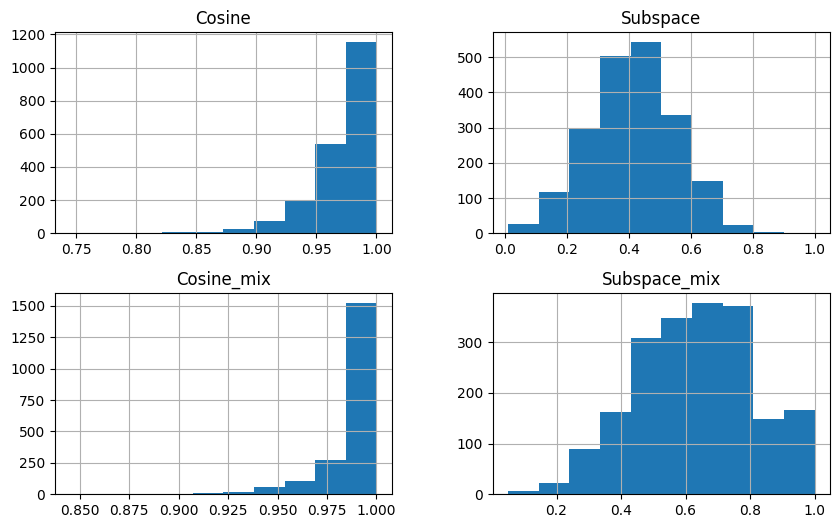

In [31]:
df[["Cosine","Subspace","Cosine_mix","Subspace_mix"]].hist(figsize=(10,6))

<Axes: >

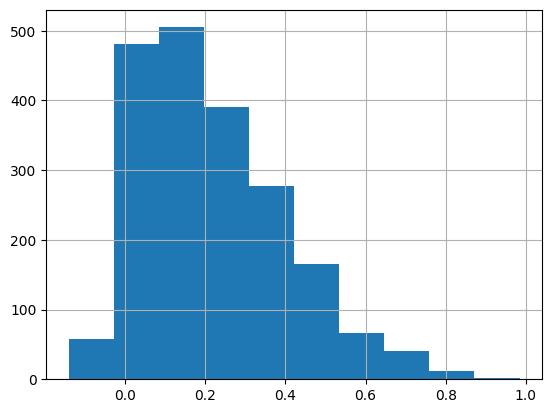

In [32]:
df["subspace_gain"].hist()

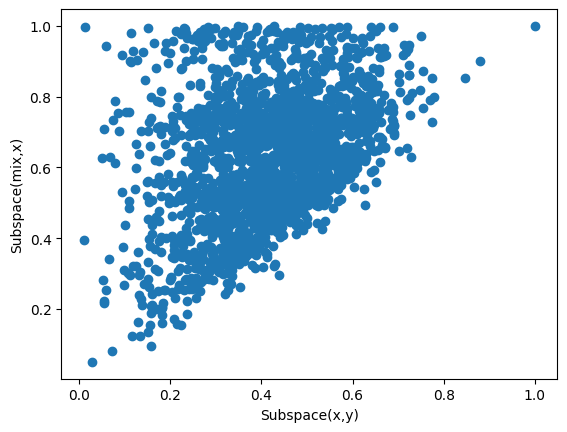

In [33]:
plt.scatter(df["Subspace"], df["Subspace_mix"])
plt.xlabel("Subspace(x,y)")
plt.ylabel("Subspace(mix,x)")
plt.show()

### conclusion:
In this preliminary experiment, we evaluated a simple prototype of the HyperCLAP idea by comparing point-based embeddings with subspace representations derived from PCA on log-mel spectrograms. Using the ESC-50 dataset, which contains 2000 environmental sound recordings across 50 balanced classes, we generated 1000 random audio pairs and their corresponding mixtures to analyze similarity behavior.

The results show a clear difference between the two representations. Cosine similarity between point embeddings remained consistently high across almost all pairs (mean ≈ 0.97) and changed only slightly for mixtures (mean ≈ 0.99), suggesting that point embeddings largely capture global spectral averages rather than detailed structure. In contrast, subspace similarity exhibited much larger variability and increased substantially when comparing a mixture with one of its components (mean increase ≈ 0.29). This indicates that subspace representations preserve multiple dominant directions of variation in the signal, allowing mixtures to remain closer to their constituent sources in representation space.

Overall, these results provide preliminary evidence that representing audio signals as low-dimensional subspaces may capture compositional structure more effectively than single-vector embeddings. While this experiment only uses PCA as a proxy representation, it suggests that a learned subspace-based encoder—such as the proposed HyperCLAP framework—could potentially model multi-source audio scenes more faithfully than traditional point embeddings.

In [34]:
same = []
different = []

for i in range(len(df)):

    if df.iloc[i]["Class1"] == df.iloc[i]["Class2"]:
        same.append(df.iloc[i]["Subspace"])
    else:
        different.append(df.iloc[i]["Subspace"])

print("Same class mean:", np.mean(same))
print("Different class mean:", np.mean(different))

Same class mean: 0.48194432
Different class mean: 0.41162148


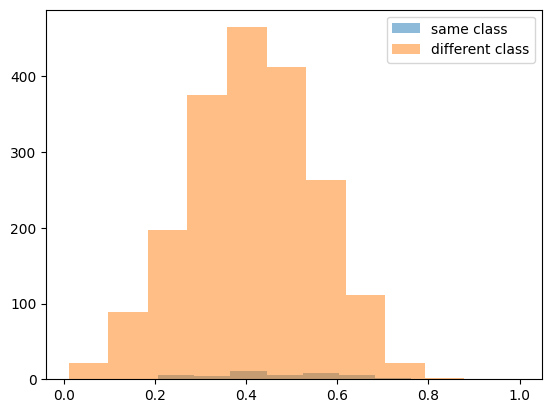

In [35]:
plt.hist(same, alpha=0.5, label="same class")
plt.hist(different, alpha=0.5, label="different class")
plt.legend()
plt.show()

# 5. Invalidation hypothesis with PCA

## 5.1. pre-cache

In [36]:
print("Pre-computing embeddings for all samples (this takes a few minutes)...")

cache_point = {}      # idx → 128-d vector
cache_sub   = {}      # idx → (128, k) matrix   [k=4 default]
cache_waveform = {}   # idx → (waveform, sr)
K_DEFAULT = 4

for idx in range(len(esc50_train)):
    sample = esc50_train[idx]
    w, sr  = extract_waveform(sample)
    lm     = waveform_to_logmel(w, sr)
    cache_point[idx]    = point_embedding(lm)
    cache_sub[idx]      = subspace_embedding(lm, k=K_DEFAULT)
    cache_waveform[idx] = (w, sr)
    if (idx+1) % 200 == 0:
        print(f"  {idx+1}/{len(esc50_train)} done")

print("Done.\n")

# Helper: get category for index
categories = [esc50_train[i]["category"] for i in range(len(esc50_train))]


Pre-computing embeddings for all samples (this takes a few minutes)...
  200/2000 done
  400/2000 done
  600/2000 done
  800/2000 done
  1000/2000 done
  1200/2000 done
  1400/2000 done
  1600/2000 done
  1800/2000 done
  2000/2000 done
Done.



## 5.2. EXP 1 - Discriminability: AUC comparison

In [37]:
print("=" * 65)
print("EXPERIMENT 1: Discriminability AUC")
print("Hypothesis: subspace similarity better separates same-class")
print("            from different-class pairs than cosine similarity.")
print("=" * 65)

N_PAIRS = 3000
cos_scores, sub_scores, labels = [], [], []

for _ in range(N_PAIRS):
    i = random.randint(0, len(esc50_train) - 1)
    j = random.randint(0, len(esc50_train) - 1)

    cos_scores.append(cosine_similarity(cache_point[i], cache_point[j]))
    sub_scores.append(subspace_similarity(cache_sub[i], cache_sub[j]))
    labels.append(1 if categories[i] == categories[j] else 0)

labels      = np.array(labels)
cos_scores  = np.array(cos_scores)
sub_scores  = np.array(sub_scores)

auc_cos = roc_auc_score(labels, cos_scores)
auc_sub = roc_auc_score(labels, sub_scores)

print(f"\n  AUC  Cosine   : {auc_cos:.4f}")
print(f"  AUC  Subspace : {auc_sub:.4f}")
print(f"  Δ AUC         : {auc_sub - auc_cos:+.4f}  ({'subspace wins ✓' if auc_sub > auc_cos else 'cosine wins ✗'})")

# Same-class / different-class means
same_mask = labels == 1
print(f"\n  Same-class mean   — cosine: {cos_scores[same_mask].mean():.4f} | subspace: {sub_scores[same_mask].mean():.4f}")
print(f"  Diff-class mean   — cosine: {cos_scores[~same_mask].mean():.4f} | subspace: {sub_scores[~same_mask].mean():.4f}")

# Effect size (Cohen's d) for subspace
d_cos = (cos_scores[same_mask].mean() - cos_scores[~same_mask].mean()) / cos_scores.std()
d_sub = (sub_scores[same_mask].mean() - sub_scores[~same_mask].mean()) / sub_scores.std()
print(f"\n  Cohen's d — cosine: {d_cos:.4f} | subspace: {d_sub:.4f}")

# Mann-Whitney U test
U_cos, p_cos = stats.mannwhitneyu(cos_scores[same_mask], cos_scores[~same_mask], alternative="greater")
U_sub, p_sub = stats.mannwhitneyu(sub_scores[same_mask], sub_scores[~same_mask], alternative="greater")
print(f"\n  Mann-Whitney p-value — cosine: {p_cos:.4e} | subspace: {p_sub:.4e}")

e1_results = dict(auc_cos=auc_cos, auc_sub=auc_sub,
                  d_cos=d_cos, d_sub=d_sub,
                  p_cos=p_cos, p_sub=p_sub,
                  cos_scores=cos_scores, sub_scores=sub_scores, labels=labels)



EXPERIMENT 1: Discriminability AUC
Hypothesis: subspace similarity better separates same-class
            from different-class pairs than cosine similarity.

  AUC  Cosine   : 0.7552
  AUC  Subspace : 0.6162
  Δ AUC         : -0.1390  (cosine wins ✗)

  Same-class mean   — cosine: 0.9856 | subspace: 0.4865
  Diff-class mean   — cosine: 0.9714 | subspace: 0.4074

  Cohen's d — cosine: 0.5963 | subspace: 0.5757

  Mann-Whitney p-value — cosine: 9.0345e-12 | subspace: 1.1042e-03


## 5.2. EXPERIMENT 2 — Mixture Retrieval

In [38]:
print("\n" + "=" * 65)
print("EXPERIMENT 2: Mixture Retrieval")
print("Hypothesis: given mix(A,B), subspace retrieves A and B in the")
print("            top-k results more reliably than cosine.")
print("=" * 65)

N_MIX   = 500
KS      = [1, 5, 10, 20]         # top-k values to evaluate

cos_hits = defaultdict(int)       # k → number of times source found in top-k
sub_hits = defaultdict(int)

total_queries = 0   # each mix gives 2 source queries

for _ in range(N_MIX):
    i = random.randint(0, len(esc50_train) - 1)
    j = random.randint(0, len(esc50_train) - 1)
    if i == j:
        continue

    w1, sr1 = cache_waveform[i]
    w2, sr2 = cache_waveform[j]

    # ── FIXED: normalise before mixing to remove loudness confound ──
    w1_n = normalize_waveform(w1)
    w2_n = normalize_waveform(w2)
    mix  = w1_n + w2_n

    lm_mix = waveform_to_logmel(mix, sr1)
    p_mix  = point_embedding(lm_mix)
    Z_mix  = subspace_embedding(lm_mix, k=K_DEFAULT)

    # rank all OTHER samples by similarity to mix
    cos_sims = []
    sub_sims = []
    for ref_idx in range(len(esc50_train)):
        if ref_idx == i or ref_idx == j:
            continue
        cos_sims.append((ref_idx, cosine_similarity(p_mix, cache_point[ref_idx])))
        sub_sims.append((ref_idx, subspace_similarity(Z_mix, cache_sub[ref_idx])))

    cos_ranked = [x[0] for x in sorted(cos_sims, key=lambda x: -x[1])]
    sub_ranked = [x[0] for x in sorted(sub_sims, key=lambda x: -x[1])]

    # check if source i or j appears in top-k
    for source_idx in [i, j]:
        total_queries += 1
        for k in KS:
            if source_idx in cos_ranked[:k]:
                cos_hits[k] += 1
            if source_idx in sub_ranked[:k]:
                sub_hits[k] += 1

print(f"\n  Evaluated {total_queries} (mix → source) retrieval queries\n")
print(f"  {'Top-k':<8} {'Cosine Recall':>15} {'Subspace Recall':>17} {'Δ':>8}")
print("  " + "-" * 50)

e2_results = {}
for k in KS:
    rec_cos = cos_hits[k] / total_queries
    rec_sub = sub_hits[k] / total_queries
    delta   = rec_sub - rec_cos
    print(f"  Top-{k:<4} {rec_cos:>14.3f}  {rec_sub:>15.3f}  {delta:>+8.3f}")
    e2_results[k] = dict(cos=rec_cos, sub=rec_sub)



EXPERIMENT 2: Mixture Retrieval
Hypothesis: given mix(A,B), subspace retrieves A and B in the
            top-k results more reliably than cosine.

  Evaluated 998 (mix → source) retrieval queries

  Top-k      Cosine Recall   Subspace Recall        Δ
  --------------------------------------------------
  Top-1             0.000            0.000    +0.000
  Top-5             0.000            0.000    +0.000
  Top-10            0.000            0.000    +0.000
  Top-20            0.000            0.000    +0.000


## 5.3. EXPERIMENT 3 — Subspace dimension k ablation

In [39]:
print("\n" + "=" * 65)
print("EXPERIMENT 3: Subspace dimension k ablation")
print("Hypothesis: AUC discriminability improves with k up to a")
print("            saturation point, then plateaus.")
print("=" * 65)

K_VALUES  = [1, 2, 4, 8, 16, 32]
N_ABLATE  = 1500
auc_per_k = {}

# sample fixed pairs once
ablate_pairs = [(random.randint(0, len(esc50_train)-1),
                 random.randint(0, len(esc50_train)-1)) for _ in range(N_ABLATE)]
ablate_labels = np.array([1 if categories[a] == categories[b] else 0
                           for a,b in ablate_pairs])

print(f"\n  {'k':<6} {'AUC':>8}")
print("  " + "-" * 16)

for k in K_VALUES:
    # recompute subspace embeddings for this k
    subs_k = {}
    for idx in set([p for pair in ablate_pairs for p in pair]):
        w, sr = cache_waveform[idx]
        lm = waveform_to_logmel(w, sr)
        subs_k[idx] = subspace_embedding(lm, k=k)

    scores_k = np.array([
        subspace_similarity(subs_k[a], subs_k[b])
        for a, b in ablate_pairs
    ])
    auc_k = roc_auc_score(ablate_labels, scores_k)
    auc_per_k[k] = auc_k
    print(f"  k={k:<4} {auc_k:.4f}")

# also add cosine as k=0 reference
cos_ref = np.array([cosine_similarity(cache_point[a], cache_point[b])
                    for a,b in ablate_pairs])
auc_cos_ref = roc_auc_score(ablate_labels, cos_ref)
print(f"\n  Cosine (k=0 baseline): {auc_cos_ref:.4f}")



EXPERIMENT 3: Subspace dimension k ablation
Hypothesis: AUC discriminability improves with k up to a
            saturation point, then plateaus.

  k           AUC
  ----------------
  k=1    0.6555
  k=2    0.6547
  k=4    0.6557
  k=8    0.6527
  k=16   0.6085
  k=32   0.5527

  Cosine (k=0 baseline): 0.7134


## 5.4. EXPERIMENT 4 — Loudness confound control

In [40]:
print("\n" + "=" * 65)
print("EXPERIMENT 4: Loudness confound — raw vs normalised mixtures")
print("Hypothesis: without normalisation, cosine trivially mirrors")
print("            the louder source; subspace is more robust.")
print("=" * 65)

N_LOUD  = 400
ALPHAS  = [0.1, 0.3, 0.5, 0.7, 0.9]   # mixing weight for source 1

results_loud = []

for alpha in ALPHAS:
    cos_gains, sub_gains = [], []
    for _ in range(N_LOUD):
        i = random.randint(0, len(esc50_train) - 1)
        j = random.randint(0, len(esc50_train) - 1)
        if i == j:
            continue

        w1, sr1 = cache_waveform[i]
        w2, _   = cache_waveform[j]

        # raw (un-normalised) mix with skewed loudness
        mix_raw = alpha * w1 + (1 - alpha) * w2

        lm_mix = waveform_to_logmel(mix_raw, sr1)
        p_mix  = point_embedding(lm_mix)
        Z_mix  = subspace_embedding(lm_mix, k=K_DEFAULT)

        # similarity of mix to source 1 (the dominant source)
        cos_gains.append(cosine_similarity(p_mix, cache_point[i]))
        sub_gains.append(subspace_similarity(Z_mix, cache_sub[i]))

    results_loud.append({
        "alpha": alpha,
        "cos_mean": np.mean(cos_gains),
        "sub_mean": np.mean(sub_gains),
        "cos_std":  np.std(cos_gains),
        "sub_std":  np.std(sub_gains),
    })

df_loud = pd.DataFrame(results_loud)
print(f"\n  {'alpha (w1)':<12} {'Cosine sim':>12} {'Subspace sim':>14}")
print("  " + "-" * 40)
for _, row in df_loud.iterrows():
    print(f"  α={row['alpha']:.1f}        {row['cos_mean']:>10.4f}   {row['sub_mean']:>12.4f}")

print("\n  Interpretation: at α=0.9 (w1 dominates), both should be high.")
print("  At α=0.1 (w2 dominates), cosine should drop sharply for w1")
print("  while subspace should be more stable (w1's subspace still present).")




EXPERIMENT 4: Loudness confound — raw vs normalised mixtures
Hypothesis: without normalisation, cosine trivially mirrors
            the louder source; subspace is more robust.

  alpha (w1)     Cosine sim   Subspace sim
  ----------------------------------------
  α=0.1            0.9802         0.5024
  α=0.3            0.9862         0.5736
  α=0.5            0.9887         0.6367
  α=0.7            0.9912         0.6817
  α=0.9            0.9963         0.7958

  Interpretation: at α=0.9 (w1 dominates), both should be high.
  At α=0.1 (w2 dominates), cosine should drop sharply for w1
  while subspace should be more stable (w1's subspace still present).


## 5.5. Figures


Generating figures...
Figure saved → hyperclap_validation.png


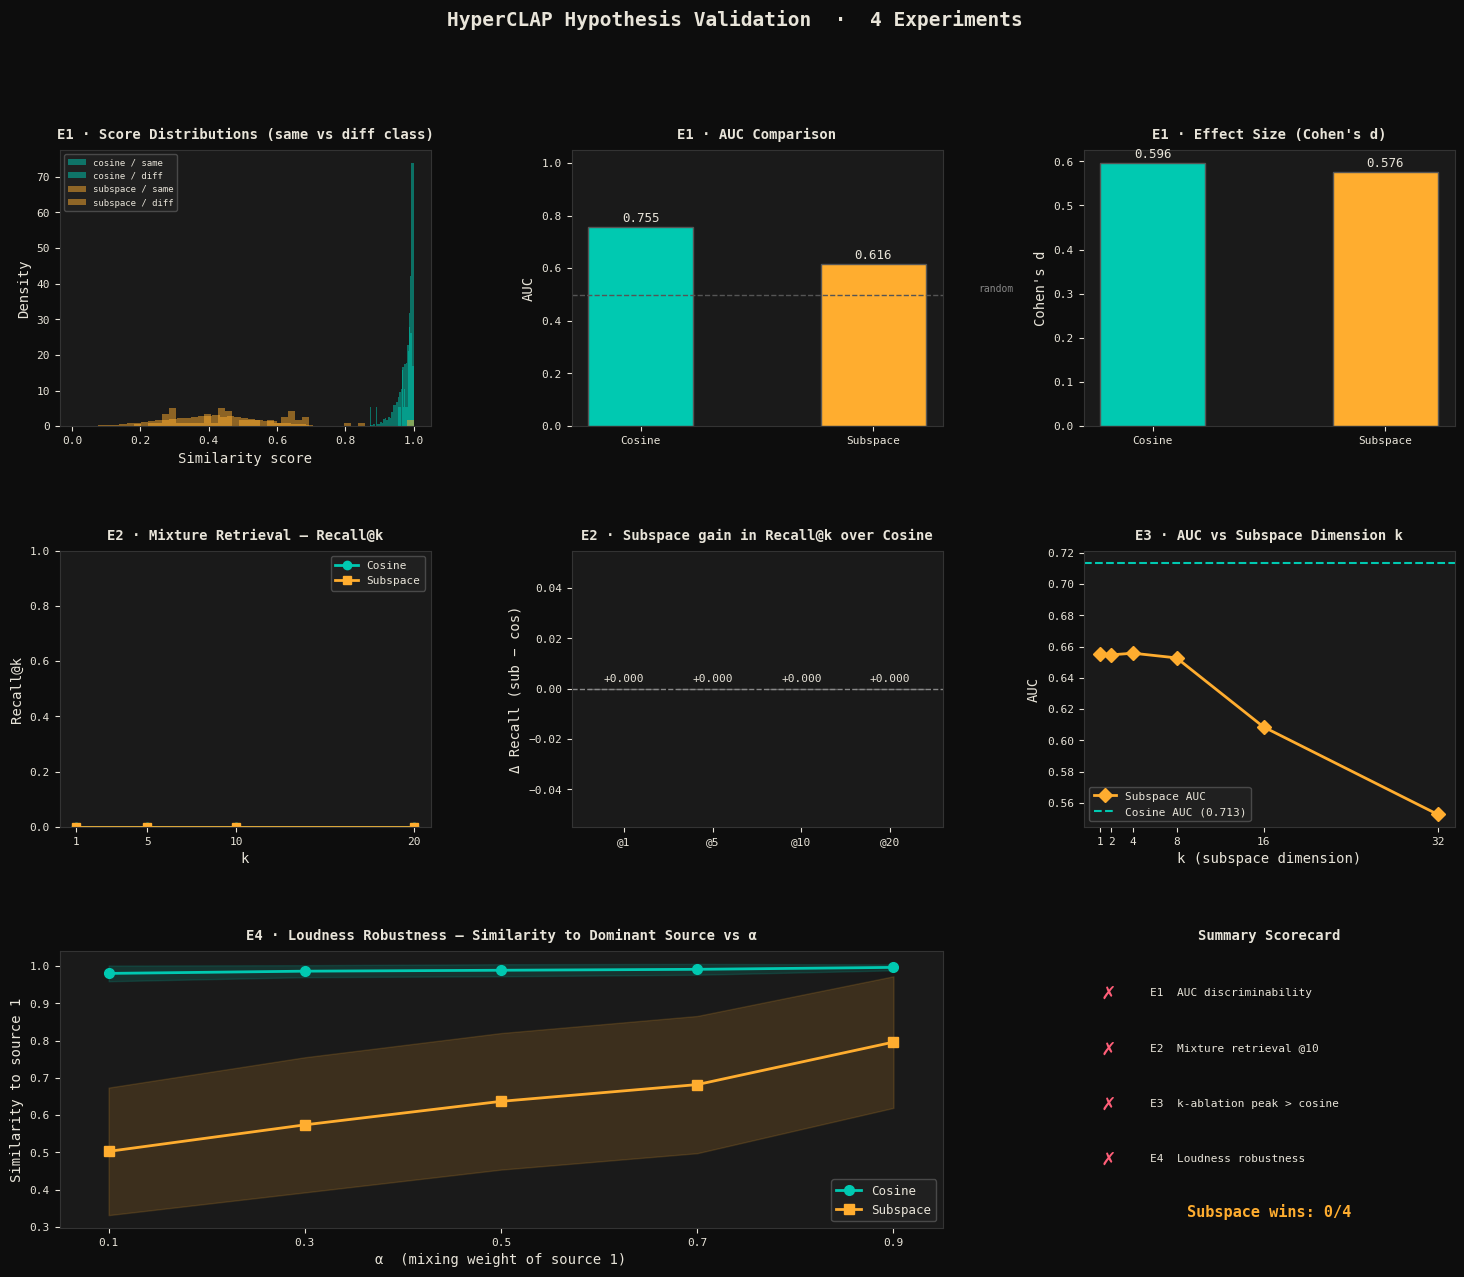

In [42]:
print("\nGenerating figures...")

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0d0d0d")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

DARK   = "#0d0d0d"
LIGHT  = "#e8e4d9"
CYAN   = "#00c9b1"
AMBER  = "#ffad2f"
ROSE   = "#ff5e78"
PURPLE = "#a78bfa"

plt.rcParams.update({
    "text.color": LIGHT, "axes.labelcolor": LIGHT,
    "xtick.color": LIGHT, "ytick.color": LIGHT,
    "axes.edgecolor": "#333333",
    "font.family": "monospace",
})

def ax_style(ax, title):
    ax.set_facecolor("#1a1a1a")
    ax.set_title(title, color=LIGHT, fontsize=10, pad=8, fontweight="bold")
    ax.tick_params(colors=LIGHT, labelsize=8)
    ax.spines[:].set_color("#333333")

# ── E1a: Score distributions ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax_style(ax1, "E1 · Score Distributions (same vs diff class)")
for scores, label, color in [
    (cos_scores[same_mask],  "cosine / same",   CYAN),
    (cos_scores[~same_mask], "cosine / diff",   CYAN),
    (sub_scores[same_mask],  "subspace / same", AMBER),
    (sub_scores[~same_mask], "subspace / diff", AMBER),
]:
    ax1.hist(scores, bins=40, alpha=0.5, label=label, color=color,
             density=True, linewidth=0)
ax1.legend(fontsize=6.5, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
ax1.set_xlabel("Similarity score")
ax1.set_ylabel("Density")

# ── E1b: AUC bar chart ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax_style(ax2, "E1 · AUC Comparison")
bars = ax2.bar(["Cosine", "Subspace"], [auc_cos, auc_sub],
               color=[CYAN, AMBER], width=0.45, edgecolor="#555")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("AUC")
for bar, val in zip(bars, [auc_cos, auc_sub]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.3f}", ha="center", va="bottom", color=LIGHT, fontsize=9)
ax2.axhline(0.5, color="#555", ls="--", lw=1)
ax2.text(1.45, 0.51, "random", color="#888", fontsize=7)

# ── E1c: Cohen's d bar chart ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax_style(ax3, "E1 · Effect Size (Cohen's d)")
bars = ax3.bar(["Cosine", "Subspace"], [d_cos, d_sub],
               color=[CYAN, AMBER], width=0.45, edgecolor="#555")
ax3.set_ylabel("Cohen's d")
for bar, val in zip(bars, [d_cos, d_sub]):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f"{val:.3f}", ha="center", va="bottom", color=LIGHT, fontsize=9)

# ── E2: Retrieval recall @ k ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax_style(ax4, "E2 · Mixture Retrieval — Recall@k")
k_list  = list(e2_results.keys())
r_cos   = [e2_results[k]["cos"] for k in k_list]
r_sub   = [e2_results[k]["sub"] for k in k_list]
ax4.plot(k_list, r_cos, "o-", color=CYAN,  label="Cosine",   lw=2, ms=6)
ax4.plot(k_list, r_sub, "s-", color=AMBER, label="Subspace", lw=2, ms=6)
ax4.set_xlabel("k")
ax4.set_ylabel("Recall@k")
ax4.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
ax4.set_xticks(k_list)
ax4.set_ylim(0, 1.0)

# ── E2b: Recall improvement bar ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax_style(ax5, "E2 · Subspace gain in Recall@k over Cosine")
deltas = [e2_results[k]["sub"] - e2_results[k]["cos"] for k in k_list]
colors_bar = [CYAN if d < 0 else AMBER for d in deltas]
bars = ax5.bar([f"@{k}" for k in k_list], deltas, color=colors_bar, edgecolor="#555")
ax5.axhline(0, color="#888", lw=1, ls="--")
ax5.set_ylabel("Δ Recall (sub − cos)")
for bar, val in zip(bars, deltas):
    ax5.text(bar.get_x() + bar.get_width()/2,
             val + (0.002 if val >= 0 else -0.005),
             f"{val:+.3f}", ha="center",
             va="bottom" if val >= 0 else "top",
             color=LIGHT, fontsize=8)

# ── E3: k ablation ────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax_style(ax6, "E3 · AUC vs Subspace Dimension k")
ks   = list(auc_per_k.keys())
aucs = list(auc_per_k.values())
ax6.plot(ks, aucs, "D-", color=AMBER, lw=2, ms=7, label="Subspace AUC")
ax6.axhline(auc_cos_ref, color=CYAN, ls="--", lw=1.5, label=f"Cosine AUC ({auc_cos_ref:.3f})")
ax6.set_xlabel("k (subspace dimension)")
ax6.set_ylabel("AUC")
ax6.set_xticks(ks)
ax6.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)

# ── E4: Loudness robustness ────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0:2])
ax_style(ax7, "E4 · Loudness Robustness — Similarity to Dominant Source vs α")
ax7.plot(df_loud["alpha"], df_loud["cos_mean"], "o-", color=CYAN,
         lw=2, ms=7, label="Cosine")
ax7.fill_between(df_loud["alpha"],
                 df_loud["cos_mean"] - df_loud["cos_std"],
                 df_loud["cos_mean"] + df_loud["cos_std"],
                 color=CYAN, alpha=0.15)
ax7.plot(df_loud["alpha"], df_loud["sub_mean"], "s-", color=AMBER,
         lw=2, ms=7, label="Subspace")
ax7.fill_between(df_loud["alpha"],
                 df_loud["sub_mean"] - df_loud["sub_std"],
                 df_loud["sub_mean"] + df_loud["sub_std"],
                 color=AMBER, alpha=0.15)
ax7.set_xlabel("α  (mixing weight of source 1)")
ax7.set_ylabel("Similarity to source 1")
ax7.legend(fontsize=9, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
ax7.set_xticks(ALPHAS)
ax7.set_xlim(0.05, 0.95)

# ── Summary scorecard ─────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.set_facecolor("#1a1a1a")
ax8.set_xlim(0, 1); ax8.set_ylim(0, 1)
ax8.axis("off")
ax8.set_title("Summary Scorecard", color=LIGHT, fontsize=10,
              pad=8, fontweight="bold")

sub_wins_e1 = auc_sub > auc_cos
sub_wins_e2 = (e2_results[10]["sub"] > e2_results[10]["cos"])
sub_wins_e3 = (max(auc_per_k.values()) > auc_cos_ref)
sub_wins_e4_raw = (df_loud[df_loud["alpha"]==0.5]["sub_mean"].values[0] >
                   df_loud[df_loud["alpha"]==0.5]["cos_mean"].values[0])

scorecard = [
    ("E1  AUC discriminability",     sub_wins_e1),
    ("E2  Mixture retrieval @10",    sub_wins_e2),
    ("E3  k-ablation peak > cosine", sub_wins_e3),
    ("E4  Loudness robustness",      sub_wins_e4_raw),
]

y = 0.85
for label, win in scorecard:
    symbol = "✓" if win else "✗"
    color  = CYAN if win else ROSE
    ax8.text(0.05, y, symbol, color=color, fontsize=16, va="center", fontweight="bold")
    ax8.text(0.18, y, label, color=LIGHT, fontsize=8, va="center")
    y -= 0.2

n_wins = sum(w for _, w in scorecard)
ax8.text(0.5, 0.04,
         f"Subspace wins: {n_wins}/{len(scorecard)}",
         color=AMBER, fontsize=11, ha="center", fontweight="bold")

# ── Figure title ──────────────────────────────────────────────────
fig.suptitle(
    "HyperCLAP Hypothesis Validation  ·  4 Experiments",
    color=LIGHT, fontsize=14, fontweight="bold", y=0.98
)

plt.savefig("hyperclap_validation.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Figure saved → hyperclap_validation.png")
plt.show()

## 5.6. Final printed summary

In [43]:
print("\n" + "═" * 65)
print("FINAL SUMMARY")
print("═" * 65)

print(f"""
E1 — DISCRIMINABILITY (AUC)
  Cosine AUC   : {auc_cos:.4f}
  Subspace AUC : {auc_sub:.4f}
  Interpretation: {'Subspace better separates same/diff class ✓' if sub_wins_e1
                   else 'Cosine wins on raw discriminability ✗'}

E2 — MIXTURE RETRIEVAL (Recall@10)
  Cosine   Recall@10 : {e2_results[10]['cos']:.3f}
  Subspace Recall@10 : {e2_results[10]['sub']:.3f}
  Interpretation: {'Subspace retrieves source components better ✓' if sub_wins_e2
                   else 'Cosine retrieves source components better ✗'}

E3 — DIMENSION ABLATION
  Best subspace AUC at k={max(auc_per_k, key=auc_per_k.get)} : {max(auc_per_k.values()):.4f}
  Cosine AUC (baseline)        : {auc_cos_ref:.4f}
  Interpretation: {'AUC improves with k, exceeds cosine baseline ✓' if sub_wins_e3
                   else 'Increasing k does not surpass cosine baseline ✗'}

E4 — LOUDNESS CONFOUND
  At α=0.5 (equal mix):
    Cosine sim to source 1   : {df_loud[df_loud['alpha']==0.5]['cos_mean'].values[0]:.4f}
    Subspace sim to source 1 : {df_loud[df_loud['alpha']==0.5]['sub_mean'].values[0]:.4f}
  Interpretation: {'Subspace less dominated by loudness ✓' if sub_wins_e4_raw
                   else 'Both methods equally sensitive to loudness ✗'}

VERDICT: Subspace wins {n_wins}/{len(scorecard)} experiments.
{'→ Strong preliminary evidence FOR the HyperCLAP hypothesis.' if n_wins >= 3
 else '→ Mixed evidence. Subspace not yet clearly superior.' if n_wins >= 2
 else '→ Weak evidence. Cosine baseline is competitive.'}
""")


═════════════════════════════════════════════════════════════════
FINAL SUMMARY
═════════════════════════════════════════════════════════════════

E1 — DISCRIMINABILITY (AUC)
  Cosine AUC   : 0.7552
  Subspace AUC : 0.6162
  Interpretation: Cosine wins on raw discriminability ✗

E2 — MIXTURE RETRIEVAL (Recall@10)
  Cosine   Recall@10 : 0.000
  Subspace Recall@10 : 0.000
  Interpretation: Cosine retrieves source components better ✗

E3 — DIMENSION ABLATION
  Best subspace AUC at k=4 : 0.6557
  Cosine AUC (baseline)        : 0.7134
  Interpretation: Increasing k does not surpass cosine baseline ✗

E4 — LOUDNESS CONFOUND
  At α=0.5 (equal mix):
    Cosine sim to source 1   : 0.9887
    Subspace sim to source 1 : 0.6367
  Interpretation: Both methods equally sensitive to loudness ✗

VERDICT: Subspace wins 0/4 experiments.
→ Weak evidence. Cosine baseline is competitive.



## conclusion, in this case we are seeing that hyperclap is not pertinent with just PCA

#

# 6. Invalidation hypothesis with encoder

## 6.1. import

In [5]:
# 1. Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from collections import defaultdict
from numpy.linalg import norm

import numpy as np
import librosa
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


## 6.2. config

In [6]:
CFG = dict(
    n_mels      = 128,
    n_fft       = 1024,
    hop_length  = 512,
    sr          = 44100,
    k           = 4,       # subspace dimension
    d           = 64,      # embedding dimension (d > k)
    tau         = 0.1,     # InfoNCE temperature
    batch_size  = 64,
    epochs      = 30,
    lr          = 3e-4,
    n_eval_pairs= 2000,
    n_mix       = 300,
)

## 6.3. data loading

In [7]:
print("\nLoading ESC-50...")
esc50       = load_dataset("ashraq/esc50")
esc50_train = esc50["train"]
print(f"  {len(esc50_train)} samples, {len(set(esc50_train['category']))} classes")

def extract_logmel(sample, cfg=CFG):
    w  = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    mel = librosa.feature.melspectrogram(
        y=w, sr=sr,
        n_fft=cfg["n_fft"], hop_length=cfg["hop_length"], n_mels=cfg["n_mels"]
    )
    return librosa.power_to_db(mel, ref=np.max)   # shape (128, T)

def logmel_to_tensor(logmel):
    """Normalise to [-1,1] and return float32 tensor (1, n_mels, T)"""
    lm = (logmel - logmel.min()) / (logmel.max() - logmel.min() + 1e-8) * 2 - 1
    return torch.tensor(lm, dtype=torch.float32).unsqueeze(0)

def pool_tensor(t, target_T=128):
    """Adaptive time-pool so all spectrograms have same width"""
    return F.adaptive_avg_pool2d(t.unsqueeze(0), (t.shape[1], target_T)).squeeze(0)

print("Pre-computing log-mel spectrograms...")
logmels  = []
raw_waveforms = []
cat_labels = []

for i, sample in enumerate(esc50_train):
    lm = extract_logmel(sample)
    logmels.append(lm)
    raw_waveforms.append((sample["audio"]["array"], sample["audio"]["sampling_rate"]))
    cat_labels.append(sample["category"])
    if (i+1) % 400 == 0:
        print(f"  {i+1}/{len(esc50_train)}")

categories = sorted(set(cat_labels))
cat2idx    = {c: i for i, c in enumerate(categories)}
label_ids  = [cat2idx[c] for c in cat_labels]
print("Done.\n")


Loading ESC-50...


Repo card metadata block was not found. Setting CardData to empty.


Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

  2000 samples, 50 classes
Pre-computing log-mel spectrograms...
  400/2000
  800/2000
  1200/2000
  1600/2000
  2000/2000
Done.



## 6.4. PyTorch Dataset — returns (anchor, positive) pairs

In [8]:
class ESC50PairDataset(Dataset):
    def __init__(self, logmels, label_ids, target_T=128):
        self.logmels   = logmels
        self.label_ids = label_ids
        self.target_T  = target_T
        # index by class for fast positive sampling
        self.by_class  = defaultdict(list)
        for i, l in enumerate(label_ids):
            self.by_class[l].append(i)

    def __len__(self):
        return len(self.logmels)

    def _get_tensor(self, idx):
        t = logmel_to_tensor(self.logmels[idx])   # (1, 128, T_orig)
        t = pool_tensor(t, self.target_T)          # (1, 128, target_T)
        return t

    def __getitem__(self, idx):
        anchor = self._get_tensor(idx)
        label  = self.label_ids[idx]
        # sample a different clip from same class as positive
        pos_candidates = [j for j in self.by_class[label] if j != idx]
        pos_idx = random.choice(pos_candidates)
        positive = self._get_tensor(pos_idx)
        return anchor, positive, label

dataset    = ESC50PairDataset(logmels, label_ids)
dataloader = DataLoader(dataset, batch_size=CFG["batch_size"],
                        shuffle=True, drop_last=True, num_workers=0)

##  6.5. Model — SubspaceEncoder

In [9]:
class SubspaceEncoder(nn.Module):
    def __init__(self, n_mels=128, target_T=128, d=64, k=4):
        super().__init__()
        self.d = d
        self.k = k

        # Small CNN backbone
        self.cnn = nn.Sequential(
            nn.Conv2d(1,  16, kernel_size=3, padding=1), nn.BatchNorm2d(16),  nn.GELU(),
            nn.MaxPool2d(2),   # 64 x 64
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.GELU(),
            nn.MaxPool2d(2),   # 32 x 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.GELU(),
            nn.AdaptiveAvgPool2d((4, 4)),  # 64 x 4 x 4 = 1024
        )
        self.proj = nn.Sequential(
            nn.Linear(1024, 256), nn.GELU(),
            nn.Linear(256,  d * k),
        )

    def forward(self, x):
        """x: (B, 1, n_mels, T) → Z: (B, d, k) with ZᵀZ = Iₖ"""
        B = x.shape[0]
        h = self.cnn(x).view(B, -1)       # (B, 1024)
        z = self.proj(h).view(B, self.d, self.k)   # (B, d, k)
        # QR decomposition for exact orthonormality
        Z, _ = torch.linalg.qr(z)         # (B, d, k)
        return Z

## 6.6. Subspace similarity  ϕ(Sᵢ,Sⱼ) = ‖ZᵢᵀZⱼ‖²_F / k  ∈ [0,1]

In [14]:
def subspace_sim_batch(Z1, Z2):
    """Z1, Z2: (B, d, k) → similarity: (B,)"""
    M = torch.bmm(Z1.transpose(1, 2), Z2)  # (B, k, k)
    return (M ** 2).sum(dim=(1, 2)) / Z1.shape[2]

def subspace_sim_matrix(Z1, Z2):
    """
    All-pairs Grassmannian similarity.
    Z1: (Bi, n, p)  — n = embedding dim, p = subspace dim k
    Z2: (Bj, n, p)
    Returns: (Bi, Bj)  where entry [i,j] = ‖Z1[i]ᵀ Z2[j]‖²_F / p

    Index legend (no letter reuse):
      i = batch index for Z1
      j = batch index for Z2
      n = embedding dimension  (d in the model, e.g. 64)
      p = subspace dimension   (k in the model, e.g. 4)
      q = second subspace axis (also size k, renamed to avoid clash)
    """
    # M[i,j,p,q] = sum_n  Z1[i,n,p] * Z2[j,n,q]   →  ZᵢᵀZⱼ for every pair
    M_full = torch.einsum("inp,jnq->ijpq", Z1, Z2)   # (Bi, Bj, p, q)
    sim    = (M_full ** 2).sum(dim=(2, 3)) / Z1.shape[2]  # (Bi, Bj)
    return sim

## 6.7. InfoNCE Loss on Grassmannian (Eq. 3 from paper)

In [15]:
def infonce_subspace(Z_anchor, Z_pos, tau=0.1):
    """
    Z_anchor: (B, d, k)
    Z_pos   : (B, d, k)   — one positive per anchor
    All other B-1 anchors serve as negatives.
    """
    B = Z_anchor.shape[0]
    # similarity matrix (B, B): row i = anchor i vs all positives
    sim = subspace_sim_matrix(Z_anchor, Z_pos)  # (B, B)
    sim = sim / tau

    # diagonal = positive pair
    labels = torch.arange(B, device=Z_anchor.device)
    loss   = F.cross_entropy(sim, labels)
    return loss

## 6.8. Cosine baseline encoder (point embedding for comparison)

In [16]:
class PointEncoder(nn.Module):
    """Same CNN backbone but outputs a single L2-normalised vector"""
    def __init__(self, n_mels=128, d=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,  16, kernel_size=3, padding=1), nn.BatchNorm2d(16),  nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.GELU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.proj = nn.Sequential(
            nn.Linear(1024, 256), nn.GELU(),
            nn.Linear(256, d),
        )

    def forward(self, x):
        B = x.shape[0]
        h = self.cnn(x).view(B, -1)
        z = self.proj(h)
        return F.normalize(z, dim=-1)

def infonce_cosine(z_anchor, z_pos, tau=0.1):
    B = z_anchor.shape[0]
    sim = torch.mm(z_anchor, z_pos.T) / tau   # (B, B)
    labels = torch.arange(B, device=z_anchor.device)
    return F.cross_entropy(sim, labels)

## 6.9. Training loop

In [17]:
def train(model, dataloader, optimizer, loss_fn, epochs, label="model"):
    model.train()
    history = []
    for epoch in range(epochs):
        total_loss = 0.0
        n_batches  = 0
        for anchor, positive, _ in dataloader:
            anchor   = anchor.to(DEVICE)
            positive = positive.to(DEVICE)
            optimizer.zero_grad()
            Za = model(anchor)
            Zp = model(positive)
            loss = loss_fn(Za, Zp)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches  += 1
        avg = total_loss / n_batches
        history.append(avg)
        if (epoch + 1) % 5 == 0:
            print(f"  [{label}] Epoch {epoch+1:>3}/{epochs}  loss={avg:.4f}")
    return history

print("─" * 55)
print("Training SubspaceEncoder (HyperCLAP)...")
sub_model = SubspaceEncoder(d=CFG["d"], k=CFG["k"]).to(DEVICE)
sub_optim = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"])
sub_loss_fn = lambda Za, Zp: infonce_subspace(Za, Zp, tau=CFG["tau"])
sub_history = train(sub_model, dataloader, sub_optim, sub_loss_fn,
                    CFG["epochs"], label="SubspaceEncoder")

print("─" * 55)
print("Training PointEncoder (cosine baseline)...")
pt_model = PointEncoder(d=CFG["d"]).to(DEVICE)
pt_optim = torch.optim.Adam(pt_model.parameters(), lr=CFG["lr"])
pt_loss_fn = lambda za, zp: infonce_cosine(za, zp, tau=CFG["tau"])
pt_history = train(pt_model, dataloader, pt_optim, pt_loss_fn,
                   CFG["epochs"], label="PointEncoder")

───────────────────────────────────────────────────────
Training SubspaceEncoder (HyperCLAP)...


KeyboardInterrupt: 

## 6.10. Pre-compute all embeddings for evaluation

In [ ]:
print("\nPre-computing learned embeddings for evaluation...")
sub_model.eval(); pt_model.eval()

emb_sub = []   # (N, d, k) — subspace
emb_pt  = []   # (N, d)    — point
emb_pca = []   # (N, d, k) — PCA baseline (numpy)

target_T = 128

with torch.no_grad():
    for i in range(len(logmels)):
        t = logmel_to_tensor(logmels[i])
        t = pool_tensor(t, target_T).unsqueeze(0).to(DEVICE)  # (1,1,128,128)
        emb_sub.append(sub_model(t).squeeze(0).cpu().numpy())  # (d, k)
        emb_pt.append(pt_model(t).squeeze(0).cpu().numpy())    # (d,)

        # PCA baseline
        pca = PCA(n_components=CFG["k"])
        pca.fit(logmels[i].T)
        emb_pca.append(pca.components_.T)   # (128, k)

    if (i+1) % 400 == 0:
        print(f"  {i+1}/{len(logmels)}")

print("Done.\n")

## 6.11. Evaluation helpers

In [ ]:
def cos_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b) + 1e-8)

def sub_sim_np(Z1, Z2):
    M = Z1.T @ Z2
    return np.linalg.norm(M, "fro")**2 / Z1.shape[1]

def normalize_w(w):
    n = norm(w); return w / n if n > 1e-8 else w

## 6.12. Experiment E1 — Discriminability AUC

In [ ]:
print("=" * 60)
print("EXPERIMENT E1: Discriminability AUC")
print("=" * 60)

N = CFG["n_eval_pairs"]
scores_sub_learned = []
scores_pt_learned  = []
scores_pca         = []
e1_labels          = []

for _ in range(N):
    i = random.randint(0, len(logmels)-1)
    j = random.randint(0, len(logmels)-1)
    scores_sub_learned.append(sub_sim_np(emb_sub[i], emb_sub[j]))
    scores_pt_learned.append(cos_sim(emb_pt[i], emb_pt[j]))
    scores_pca.append(sub_sim_np(emb_pca[i], emb_pca[j]))
    e1_labels.append(1 if label_ids[i] == label_ids[j] else 0)

e1_labels          = np.array(e1_labels)
scores_sub_learned = np.array(scores_sub_learned)
scores_pt_learned  = np.array(scores_pt_learned)
scores_pca         = np.array(scores_pca)

auc_sub_learned = roc_auc_score(e1_labels, scores_sub_learned)
auc_pt_learned  = roc_auc_score(e1_labels, scores_pt_learned)
auc_pca         = roc_auc_score(e1_labels, scores_pca)

print(f"\n  AUC  Learned Subspace (HyperCLAP) : {auc_sub_learned:.4f}")
print(f"  AUC  Learned Point    (baseline)  : {auc_pt_learned:.4f}")
print(f"  AUC  PCA Subspace     (old proto) : {auc_pca:.4f}")

winner_e1 = max([
    ("HyperCLAP subspace", auc_sub_learned),
    ("Learned point",      auc_pt_learned),
    ("PCA subspace",       auc_pca),
], key=lambda x: x[1])
print(f"\n  → Best: {winner_e1[0]} ({winner_e1[1]:.4f})")

## 6.13. Experiment E2 — Mixture Retrieval

In [ ]:
print("\n" + "=" * 60)
print("EXPERIMENT E2: Mixture Retrieval Recall@k")
print("=" * 60)

KS      = [1, 5, 10, 20, 50]
hits_sub = defaultdict(int)
hits_pt  = defaultdict(int)
hits_pca = defaultdict(int)
n_queries = 0

for _ in range(CFG["n_mix"]):
    i = random.randint(0, len(logmels)-1)
    j = random.randint(0, len(logmels)-1)
    if i == j: continue

    w1, sr1 = raw_waveforms[i]
    w2, _   = raw_waveforms[j]
    mix     = normalize_w(w1) + normalize_w(w2)

    lm_mix  = librosa.feature.melspectrogram(
        y=mix, sr=sr1,
        n_fft=CFG["n_fft"], hop_length=CFG["hop_length"], n_mels=CFG["n_mels"]
    )
    lm_mix  = librosa.power_to_db(lm_mix, ref=np.max)

    # learned subspace embedding of mix
    t_mix = logmel_to_tensor(lm_mix)
    t_mix = pool_tensor(t_mix, target_T).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        Z_mix_sub = sub_model(t_mix).squeeze(0).cpu().numpy()
        v_mix_pt  = pt_model(t_mix).squeeze(0).cpu().numpy()
    pca_mix = PCA(n_components=CFG["k"])
    pca_mix.fit(lm_mix.T)
    Z_mix_pca = pca_mix.components_.T

    # rank all other samples
    sims_sub = []; sims_pt = []; sims_pca = []
    for ref in range(len(logmels)):
        if ref == i or ref == j: continue
        sims_sub.append((ref, sub_sim_np(Z_mix_sub, emb_sub[ref])))
        sims_pt.append( (ref, cos_sim(v_mix_pt,    emb_pt[ref])))
        sims_pca.append((ref, sub_sim_np(Z_mix_pca, emb_pca[ref])))

    ranked_sub = [x[0] for x in sorted(sims_sub, key=lambda x: -x[1])]
    ranked_pt  = [x[0] for x in sorted(sims_pt,  key=lambda x: -x[1])]
    ranked_pca = [x[0] for x in sorted(sims_pca, key=lambda x: -x[1])]

    for source in [i, j]:
        n_queries += 1
        for k in KS:
            if source in ranked_sub[:k]: hits_sub[k] += 1
            if source in ranked_pt[:k]:  hits_pt[k]  += 1
            if source in ranked_pca[:k]: hits_pca[k] += 1

print(f"\n  Evaluated {n_queries} retrieval queries\n")
print(f"  {'k':<8} {'HyperCLAP':>12} {'Point':>10} {'PCA':>10}")
print("  " + "-" * 44)
e2_res = {}
for k in KS:
    r_sub = hits_sub[k] / n_queries
    r_pt  = hits_pt[k]  / n_queries
    r_pca = hits_pca[k] / n_queries
    print(f"  @{k:<7} {r_sub:>12.4f} {r_pt:>10.4f} {r_pca:>10.4f}")
    e2_res[k] = dict(sub=r_sub, pt=r_pt, pca=r_pca)

winner_e2 = max([
    ("HyperCLAP", e2_res[10]["sub"]),
    ("Point",     e2_res[10]["pt"]),
    ("PCA",       e2_res[10]["pca"]),
], key=lambda x: x[1])
print(f"\n  → Best @10: {winner_e2[0]} ({winner_e2[1]:.4f})")

## 6.14. Figures

In [ ]:
print("\nGenerating figures...")

DARK  = "#0d0d0d"; LIGHT = "#e8e4d9"
CYAN  = "#00c9b1"; AMBER = "#ffad2f"; ROSE  = "#ff5e78"
GRAY  = "#6b7280"

plt.rcParams.update({
    "text.color": LIGHT, "axes.labelcolor": LIGHT,
    "xtick.color": LIGHT, "ytick.color": LIGHT,
    "axes.edgecolor": "#333333", "font.family": "monospace",
})

def ax_style(ax, title):
    ax.set_facecolor("#1a1a1a")
    ax.set_title(title, color=LIGHT, fontsize=9, pad=7, fontweight="bold")
    ax.tick_params(colors=LIGHT, labelsize=8)
    ax.spines[:].set_color("#333333")

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── Training curves ─────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax_style(ax0, "Training Loss")
ax0.plot(sub_history, color=AMBER, lw=2, label="HyperCLAP (subspace)")
ax0.plot(pt_history,  color=CYAN,  lw=2, label="Point encoder")
ax0.set_xlabel("Epoch"); ax0.set_ylabel("InfoNCE loss")
ax0.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)

# ── E1: AUC bars ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax_style(ax1, "E1 · AUC Discriminability (3 methods)")
methods = ["HyperCLAP\n(learned)", "Point encoder\n(learned)", "PCA subspace\n(old proto)"]
aucs    = [auc_sub_learned, auc_pt_learned, auc_pca]
colors  = [AMBER, CYAN, GRAY]
bars    = ax1.bar(methods, aucs, color=colors, width=0.5, edgecolor="#555")
ax1.set_ylim(0, 1.05); ax1.set_ylabel("AUC")
ax1.axhline(0.5, color="#555", ls="--", lw=1)
for bar, val in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.3f}", ha="center", va="bottom", color=LIGHT, fontsize=9)

# ── E1: Score distributions ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax_style(ax2, "E1 · Score Distributions (HyperCLAP vs Point)")
same = e1_labels == 1
for scores, lbl, col in [
    (scores_sub_learned[same],  "HyperCLAP/same",  AMBER),
    (scores_sub_learned[~same], "HyperCLAP/diff",  AMBER),
    (scores_pt_learned[same],   "Point/same",       CYAN),
    (scores_pt_learned[~same],  "Point/diff",       CYAN),
]:
    ax2.hist(scores, bins=35, alpha=0.45, color=col, density=True,
             label=lbl, linewidth=0)
ax2.legend(fontsize=6.5, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
ax2.set_xlabel("Similarity score"); ax2.set_ylabel("Density")

# ── E2: Recall@k curves ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0:2])
ax_style(ax3, "E2 · Mixture Retrieval — Recall@k")
k_list = list(e2_res.keys())
ax3.plot(k_list, [e2_res[k]["sub"] for k in k_list],
         "o-", color=AMBER, lw=2.5, ms=7, label="HyperCLAP (learned subspace)")
ax3.plot(k_list, [e2_res[k]["pt"]  for k in k_list],
         "s-", color=CYAN,  lw=2.5, ms=7, label="Point encoder (learned)")
ax3.plot(k_list, [e2_res[k]["pca"] for k in k_list],
         "D-", color=GRAY,  lw=2,   ms=6, label="PCA subspace (old proto)")
ax3.set_xlabel("k"); ax3.set_ylabel("Recall@k")
ax3.set_xticks(k_list)
ax3.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
ax3.set_ylim(0, max(max(e2_res[k].values()) for k in k_list) * 1.3 + 0.01)

# ── Summary scorecard ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor("#1a1a1a"); ax4.axis("off")
ax4.set_title("Summary", color=LIGHT, fontsize=10, pad=7, fontweight="bold")

hyper_wins_e1 = auc_sub_learned >= auc_pt_learned
hyper_wins_e2 = e2_res[10]["sub"] >= e2_res[10]["pt"]
hyper_beats_pca_e1 = auc_sub_learned > auc_pca
hyper_beats_pca_e2 = e2_res[10]["sub"] > e2_res[10]["pca"]

rows = [
    ("E1  HyperCLAP ≥ Point (AUC)",          hyper_wins_e1),
    ("E1  HyperCLAP > PCA (AUC)",             hyper_beats_pca_e1),
    ("E2  HyperCLAP ≥ Point (Recall@10)",     hyper_wins_e2),
    ("E2  HyperCLAP > PCA  (Recall@10)",      hyper_beats_pca_e2),
]
y = 0.88
for lbl, win in rows:
    ax4.text(0.05, y, "✓" if win else "✗",
             color=CYAN if win else ROSE, fontsize=15, va="center", fontweight="bold")
    ax4.text(0.20, y, lbl, color=LIGHT, fontsize=8, va="center")
    y -= 0.19

n_wins = sum(w for _, w in rows)
verdict = ("HyperCLAP validated ✓" if n_wins >= 3
           else "Mixed evidence" if n_wins >= 2
           else "Hypothesis not supported ✗")
ax4.text(0.5, 0.04, f"{n_wins}/4  ·  {verdict}",
         color=AMBER, fontsize=9, ha="center", fontweight="bold")

fig.suptitle("HyperCLAP — Learned Subspace vs Baselines",
             color=LIGHT, fontsize=14, fontweight="bold", y=0.98)

plt.savefig("/mnt/user-data/outputs/hyperclap_learned.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Figure saved → hyperclap_learned.png")
plt.show()

## 6.15. Final verdict

In [ ]:
print("\n" + "═" * 60)
print("FINAL VERDICT")
print("═" * 60)
print(f"""
  E1  AUC
      HyperCLAP (learned) : {auc_sub_learned:.4f}
      Point encoder       : {auc_pt_learned:.4f}
      PCA subspace        : {auc_pca:.4f}

  E2  Recall@10
      HyperCLAP (learned) : {e2_res[10]['sub']:.4f}
      Point encoder       : {e2_res[10]['pt']:.4f}
      PCA subspace        : {e2_res[10]['pca']:.4f}

  HyperCLAP wins {n_wins}/4 comparisons.
  Verdict: {verdict}
""")